# Calculation of $\pi$

This exercise requires to understand the Monte-Carlo method and some basic statistical concepts. Best suited after the following notebook [Frequentist_inference_02.ipynb](../04-Basic_statistical_inference_frequentists_2/Frequentist_inference_02.ipynb) hase been covered. 

## Antiquity method:

It is often considered that this method has been devised by ancient Greeks. 

- Consider a circle of unit radius ($R=1$). Its area is $A_c = \pi$. 
- Consider the square into which this circle is inscripted. It is a square of side $s = 2$. Its area is $A_s = 4$. 

A simple strategy to calculate $\pi$ via Monte-Carlo methods consists in randomly drawing points between $[-1,1]$ along x and y / in the square. The ratio between the number of points *in* the circle and *in the square* is equal to the ratio of areas, i.e. $\pi / 4$. 

- (i) Design a simple code to estime $\pi$ based on this result.  
- (ii) Calculate the standard error on $\pi$ for $n_1=100$, $n_2=1000$ and $n_3=10000$ draws. 
- (iii) Calculate a 99% confidence interval on $\pi$ for an experiment repeated only 10 times but that uses n = 10000 points

BONUS: Generate a figure that shows how the precision increases with the number of points. 

In [14]:
import numpy as np 
import scipy.stats 
from matplotlib import pyplot as plt
%matplotlib inline

In [15]:
def calcpi(npt):
    '''
    Calculates pi based on ratio between square and circle area 
    '''
#    x, y = np.random.uniform(-1, 1, size=int(npt)), np.random.uniform(-1, 1, size=int(npt))  # use of numpy 
    x, y = scipy.stats.uniform(-1, 2).rvs(size=int(npt)), scipy.stats.uniform(-1, 2).rvs(size=int(npt))
    R = np.sqrt(x**2 + y**2)
    pi_est = 4 * float(len(R[R<=1])) / float(len(R))   # Ratio of areas = pi/4 
    return pi_est

In [30]:
# Calculate pi for an increasing number of points between 100 and 1.e6 (to plot the figure)
npt_all = np.arange(100, 1.e6, 1000, dtype=int)
pi_est = np.zeros(len(npt_all))
for i, n in enumerate(npt_all):
    pi_est[i] = calcpi(n)

(3.1, 3.18)

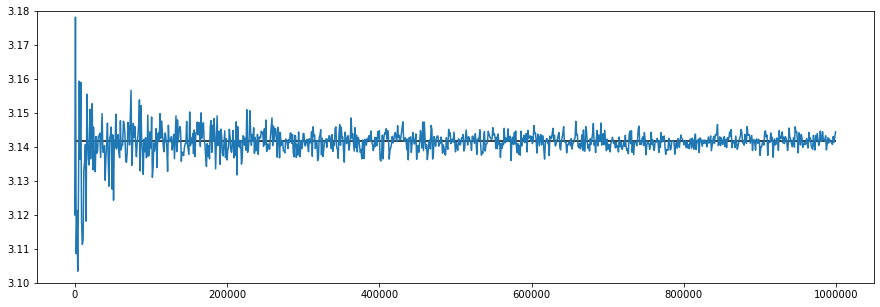

In [17]:
f = plt.figure(figsize=(15,5))
plt.plot(npt_all, pi_est)
plt.hlines(np.pi, 0, npt_all[-1])
plt.ylim(3.10, 3.18)

In [31]:
# Calculate the stde on pi for 100, 1000, 10000 points
# To do this, we need to make the calculation of pi for 100, 1000 and 10000 points a large number of times
# and look at the sample distribution on pi.
sample_test = 1000   # let's generate sample_test = 1000 realisations of pi for resp. n_1=100, n_2=1000, n_3=10000
# Creates 3 empty arrays where we will save 10000 realisations of the calculation of pi for n=100, 1000, 10000 pts
dist_100 = np.zeros(sample_test)
dist_1000 = np.zeros(sample_test)
dist_10000 = np.zeros(sample_test)
for s in range(sample_test):
    dist_100[s] = calcpi(100)
    dist_1000[s] = calcpi(1000)
    dist_10000[s] = calcpi(10000)

In [36]:
# the stde on pi is the width of the sampling distribution 

for n, dist in zip([100, 1000, 10000], [dist_100, dist_1000, dist_10000]):
    print('stde on pi = %.4f for n=%i' %(np.std(dist, ddof=1), n))
# Recalculate and save the stde for latter
stde_100 = np.std(dist_100, ddof=1)
stde_1000 = np.std(dist_1000, ddof=1)
stde_10000 = np.std(dist_10000, ddof=1)

stde on pi = 0.1661 for n=100
stde on pi = 0.0515 for n=1000
stde on pi = 0.0160 for n=10000


For each of the `sample_test=1000` realisation of the experiment, I have derived a value of $\pi$. The width of this distribution is the stde on $\pi$. 

Note that we can see that the stde scales with the square root of the number of points. 

In [37]:
# the stde scales with the square root of the number of points 

print('ratio of stde %.3f'%(stde_1000 / stde_100), 
      'is almost equal to ratio of number of points %.3f'%(np.sqrt(100)/np.sqrt(1000)))
print('ratio of stde %.3f'%(stde_10000 / stde_100), 
      'is almost equal to ratio of number of points %.3f'%(np.sqrt(100)/np.sqrt(10000)))

ratio of stde 0.310 is almost equal to ratio of number of points 0.316
ratio of stde 0.096 is almost equal to ratio of number of points 0.100


(0.16601617270615535, 0.05142977052252909)

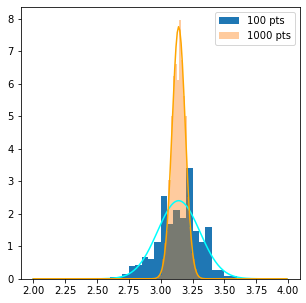

In [38]:
# Is the sampling distribution of the mean gaussian? 
x = np.arange(2,4,0.01) # sampling points for the fitted pdf of the sampling distrib. 
f, ax = plt.subplots(ncols=1, figsize=(5,5))
ax.hist(dist_100, label='100 pts', bins=20, density=True); 
mu_fit_100, sig_fit_100 = scipy.stats.norm.fit(dist_100)
ax.plot(x, scipy.stats.norm(mu_fit_100, sig_fit_100).pdf(x), color='cyan')
ax.hist(dist_1000, alpha=0.4, label='1000 pts', bins=20, density=True); 
mu_fit_1000, sig_fit_1000 = scipy.stats.norm.fit(dist_1000)
ax.plot(x, scipy.stats.norm(mu_fit_1000, sig_fit_1000).pdf(x), color='orange')
ax.legend()
sig_fit_100, sig_fit_1000

Calculation of a 99% confidence interval on $\pi$ for an experiment repeated only 10 times but that uses n = 10000 points

In [51]:
# Since the sampling distribution is to a good approximation Gaussian, we can compute a 99% CI using a Z distribution

alpha=0.01
# Create the 10 realisations of the estimate of pi with 10000 points 
pi_val = np.zeros(10)
for i in range(10):
    pi_est = calcpi(10000)
    pi_val[i] = pi_est
    
pi_mean, stde_pi = pi_val.mean(), scipy.stats.sem(pi_val)
norm_mean = scipy.stats.norm(pi_mean, stde_pi)
a1, a2 = norm_mean.ppf(alpha / 2.), norm_mean.ppf(1-alpha / 2.)
print("My %.2f percents confidence interval around %.2f is [%.2f,%.2f]" %((1-alpha) * 100., pi_mean, a1, a2))


My 99.00 percents confidence interval around 3.15 is [3.13,3.16]


## Method of Buffon's needles 

https://en.wikipedia.org/wiki/Buffon%27s_needle_problem

One draw needles of length $l$ over a over a parquet for which the width of a parquet strip is also $l$. One can show (https://en.wikipedia.org/wiki/Buffon%27s_needle_problem) that the number of needles that cross 2 strip is equal to $2 / \pi$. Create a short program to simulate the calculation of $\pi$ from the experiment (there is not need to "draw the needles on a virtual floor", just make a thought experience).  

- Calculate a 99% confidence interval on $\pi$ for an experiment repeated only 10 times but that uses n = 10000 needles. 
- - BONUS: Compare the speed of this method with the Antiquity one.


Tip: The problem can simplifies numericaly by considering that all the needles have one edge at $y = 0$ (or that the problem does not change if you translate all the needles to y =0). 

#### Solution 

We can notice that the problem is periodic => we can draw a needle such that we consider that one edge of the needle falls between two strips. => We will draw a uniform distribution between [0,1] for the first edge of the needle. 
The problem can simplifies numericaly by considering that all the needles have one edge at $y = 0$ (so we ignore y1). We can further simplify the problem by looking only to the coordinate $x2$ of the the second edge of the needle.
If this edge is $x2 > 1$ or $x2 < 0$ then it crosses a strip. If not, it is between 2 strips. The ratio between the 2 numbers is $p = 2 / \pi$.  

In [46]:
def calc_pi_buffon(npt):
    x1 = np.random.uniform(0, 1., size=int(npt)) 
    x2 = x1 + np.cos( np.random.uniform(0, 2.*np.pi, size=int(npt)) ) 
    # No need to calculate y2 as I only want to know 
    # y2 = x1*np.sin(np.random.uniform(0, 2.*np.pi, size=int(npt)))
    # number_no_cross = float(len(x2[ (x2>=0) & (x2 <= 1) ]))
    p = float(len(x2[ (x2<0) | (x2 > 1) ])) / npt  # p = 2./pi
    pi_est = 2./p
    return pi_est

In [47]:
npt_all = np.arange(100, 1.e6, 1000, dtype=int)
pi_est_b = np.zeros(len(npt_all))
for i, n in enumerate(npt_all):
    pi_est_b[i] = calc_pi_buffon(n)

(3.1, 3.18)

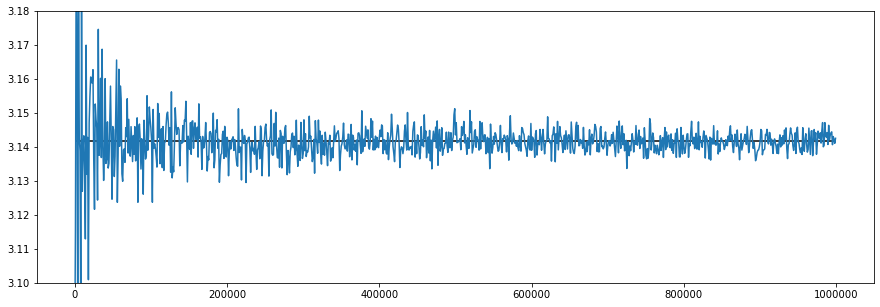

In [48]:
f = plt.figure(figsize=(15,5))
plt.plot(npt_all, pi_est_b)
plt.hlines(np.pi, 0, npt_all[-1])
plt.ylim(3.10, 3.18)

In [49]:
dist_pi_buffon = np.array([calc_pi_buffon(1000) for i in range(10000)])
dist_pi_buffon.mean()

3.142514795979215

In [52]:
# 99% CI for 10000 needles 
# 10 realisations of the experiment
dist_pi_buffon = np.array([calc_pi_buffon(10000) for i in range(10)]) 

pi_mean, stde_pi = dist_pi_buffon.mean(), scipy.stats.sem(dist_pi_buffon)
norm_mean = scipy.stats.norm(pi_mean, stde_pi)
a1, a2 = norm_mean.ppf(alpha / 2.), norm_mean.ppf(1-alpha / 2.)
print("My %.2f percents confidence interval around %.2f is [%.2f,%.2f]" %((1-alpha) * 100., pi_mean, a1, a2))


My 99.00 percents confidence interval around 3.12 is [3.11,3.14]


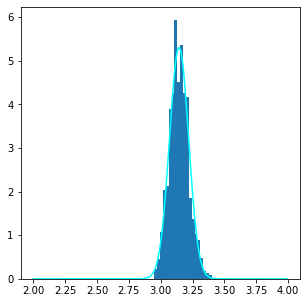

In [53]:
# In principle, we should have checked that a Normal CI was adequate ... 
# For this we could calculate the sampling distribution on pi for 10000 needles
# to save some computation, let's do it for 1000 needles
dist_pi_buffon = np.array([calc_pi_buffon(1000) for i in range(1000)])

x = np.arange(2,4,0.01) # sampling points for the fitted pdf of the sampling distrib. 
f, ax = plt.subplots(ncols=1, figsize=(5,5))
ax.hist(dist_pi_buffon, label='1000 pts', bins=20, density=True); 
mu_fit_buf, sig_fit_buf = scipy.stats.norm.fit(dist_pi_buffon)
ax.plot(x, scipy.stats.norm(mu_fit_buf, sig_fit_buf).pdf(x), color='cyan')

In [54]:
# Which method is faster: Buffon or Antiquity? 
npt=1000
%timeit calcpi(npt)

1.21 ms ± 41 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [55]:
# Buffon
npt=1000
%timeit calc_pi_buffon(npt)

44.7 µs ± 523 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


Buffon seems to be the winner ... but there is a very much faster method devised by Ramanujan ... 

## Ramanujan formula

One of the most efficient series existing to calculate $\pi$ (This is not a Monte-Carlo approach) has been devised by the Indian mathematician Ramanujan (https://fr.wikipedia.org/wiki/Srinivasa_Ramanujan). 

$$
\frac{1}{\pi} = \frac{2 \sqrt{2}}{9801} \sum_{n=0}^{\infty} \frac{(4n)!}{(n!)^4} \times \frac {1103 + 26390 n}{(4 \times 99)^{4n}}
$$

~~Implement and compare the convergence of this series compared to the other methods outlined above.~~
Calculate pi from this serie for n=0, 1, 2, 3, ... 

You will see that with such an efficient way to calculate $\pi$, we enter in a regime where numerical accuracy and float precision starts to be a bottleneck. 

In [28]:
def calcpi_ramanujan(npt):
    '''
    Returns an array with the values of the pi serie until npt
    '''
    mult_fac = 2. * np.sqrt(2) / 9801.
    pi_array = np.zeros(npt, dtype=np.float128)
    pi_array[0] = mult_fac * 1103. 
    for n in range(1, npt):
        pi_array[n] = pi_array[n-1] + mult_fac * (np.math.factorial(4 * n) / (np.math.factorial(n))**4 ) * (1103. + 26390 *n) / (4 * 99)**(4*n)
    return 1. / pi_array

In [29]:
# A manual cross check 
n = 1
mult_fac = 2. * np.sqrt(2) / 9801.
pi_0 = mult_fac * 1103. 
pi_1 = pi_0 + mult_fac * (np.math.factorial(4 * n) / (np.math.factorial(n))**4 ) * (1103. + 26390 *n) / (4 * 99)**(4*n)
n = 2
pi_2 = pi_1 + mult_fac * (np.math.factorial(4 * n) / (np.math.factorial(n))**4 ) * (1103. + 26390 *n) / (4 * 99)**(4*n)
1./pi_0, 1./pi_1, 1./pi_2

(3.1415927300133055, 3.1415926535897936, 3.141592653589793)

In [34]:
# Beware of precision display ... 
pi_ram[1], pi_ram[2]

(3.141592653589793605, 3.1415926535897929653)

In [46]:
pi_ram[0], pi_ram[1], pi_ram[2], pi_ram[3], pi_ram[4]

(3.1415927300133053872,
 3.141592653589793605,
 3.1415926535897929653,
 3.1415926535897929653,
 3.1415926535897929653)

In [47]:
np.pi

3.141592653589793